![logo](img/logoitqv1.jpg)
<br>
# 0.1 PAO26-26 - Python 101, Transformaciones
<br>

![python](img/python_logo.png)

<br>

*Kenin CUsme*

<br>

[link de Git Hub](https://github.com/kenin395/Machine-Learning.git)

Image dimensions:  (256, 256, 3)


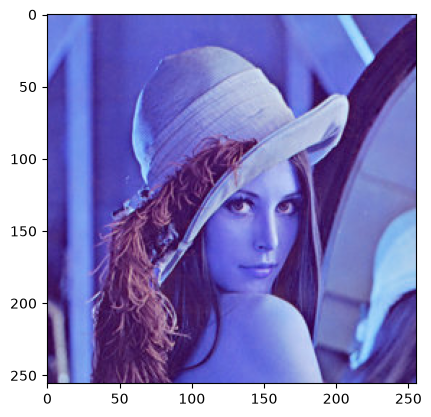

In [3]:
# READ AN IMAGE
# pip install opencv-python
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/Lena_RGB.png')
print('Image dimensions: ', np.shape(img))
plt.imshow(img, cmap='gray')
plt.show()


In [4]:
# Extraer por separado la imagen de grises de cada canal
R = img[:,:,2]
G = img[:,:,1]
B = img[:,:,0]


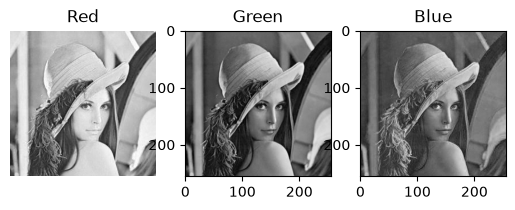

In [5]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red'), ax[0].axis('off')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()


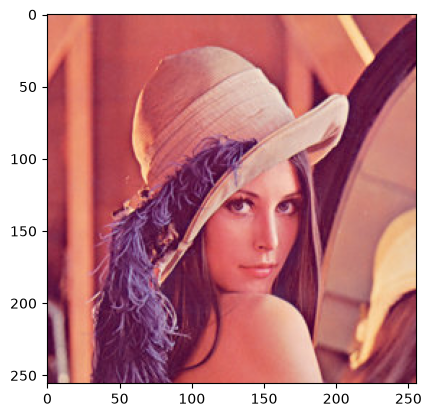

In [6]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()


0.0.1 TRANSFORMACIONES DE INTENSIDAD

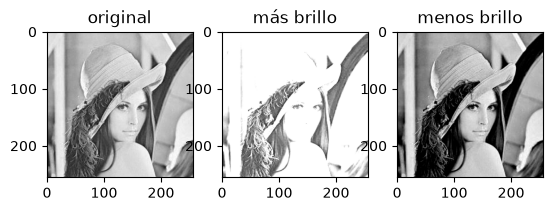

In [15]:
# CAMBIO DE BRILLO
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,2] # red color
mas_brillo = 100
menos_brillo = -100
1
mas_brillo_img = cv2.add(img, mas_brillo) # Importante el "cv2.add" en vez de␣
"+"
menos_brillo_img = cv2.add(img, menos_brillo)
fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()


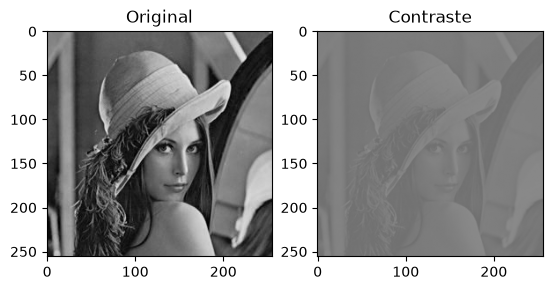

In [21]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread('images/Lena_RGB.png')
img = img[:, :, 1]  # canal verde

contraste = -100
f = 131 * (contraste + 127) / (127 * (131 - contraste))
alpha_c = f
gamma_c = 127 * (1 - f)

contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

fig, ax = plt.subplots(1, 2)

ax[0].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')

ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Contraste')

plt.show()

0.0.2 CONVERSIONES DEL ESPACIO DE COLOR

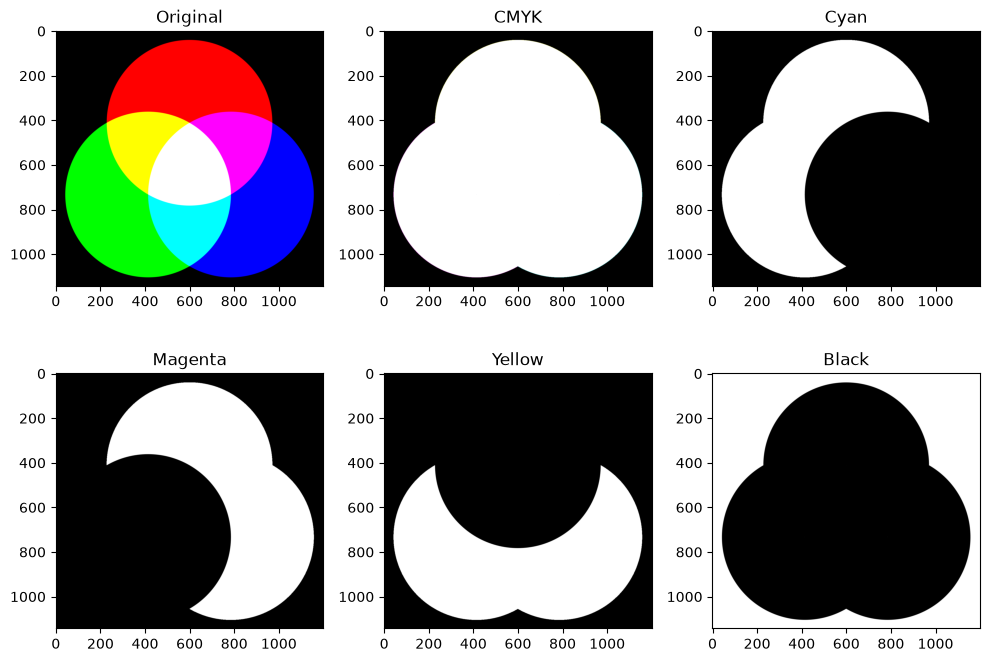

In [51]:
import numpy as np          
import cv2                  # Biblioteca OpenCV para procesamiento de imágenes
import matplotlib.pyplot as plt 
from skimage import io      

# Leer la imagen desde la carpeta 'images'
img = io.imread('images/colores.png')

# Crear una copia de la imagen original
rgb = img.copy()

# Convertir los valores de los píxeles de 0-255 a 0-1
# Esto facilita realizar las operaciones matemáticas del modelo CMYK
rgb_p = rgb.astype(np.float32) / 255

# Evita advertencias cuando se produzcan divisiones entre cero
with np.errstate(invalid='ignore', divide='ignore'):

    # Calcular el canal K (Black)
    # K = 1 - max(R,G,B)
    K = 1 - np.max(rgb_p, axis=2)

    # Calcular el canal C (Cyan)
    C = (1 - rgb_p[:, :, 2] - K) / (1 - K)

    # Calcular el canal M (Magenta)
    M = (1 - rgb_p[:, :, 1] - K) / (1 - K)

    # Calcular el canal Y (Yellow)
    Y = (1 - rgb_p[:, :, 0] - K) / (1 - K)

# Cuando un píxel es completamente negro (K=1),
# aparecen valores NaN debido a una división entre cero.
# Esta función reemplaza esos NaN por 0.
C = np.nan_to_num(C)
M = np.nan_to_num(M)
Y = np.nan_to_num(Y)

# Unir los cuatro canales (C, M, Y y K)
# Multiplicar por 255 para volver al rango de imágenes de 8 bits
CMYK = (np.dstack((C, M, Y, K)) * 255).astype('uint8')

# Separar nuevamente cada canal para poder visualizarlo
C, M, Y, K = cv2.split(CMYK)

# Crear una figura de 2 filas y 3 columnas
fig, ax = plt.subplots(2, 3, figsize=(10, 7))

# Mostrar la imagen original
ax[0,0].imshow(img)
ax[0,0].set_title('Original')

# Mostrar la imagen formada por los cuatro canales CMYK
ax[0,1].imshow(CMYK)
ax[0,1].set_title('CMYK')

# Mostrar el canal Cyan
ax[0,2].imshow(C, cmap='gray')
ax[0,2].set_title('Cyan')

# Mostrar el canal Magenta
ax[1,0].imshow(M, cmap='gray')
ax[1,0].set_title('Magenta')

# Mostrar el canal Yellow
ax[1,1].imshow(Y, cmap='gray')
ax[1,1].set_title('Yellow')

# Mostrar el canal Black (K)
ax[1,2].imshow(K, cmap='gray')
ax[1,2].set_title('Black')

# Ajustar automáticamente los espacios entre las imágenes
plt.tight_layout()

# Mostrar todas las imágenes en pantalla
plt.show()

In [47]:
import cv2
from skimage import io

# Leer la imagen
img = cv2.imread('images/Lena_RGB.png')  # Cambia la ruta si es necesario

# Verificar que la imagen se cargó correctamente
if img is None:
    print("Error: No se pudo cargar la imagen.")
else:
    # Conversión a escala de grises
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Conversión al espacio de color HSV
    # H: Hue (tono), S: Saturation (saturación), V: Value (brillo)
    HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Conversión al espacio de color Lab
    # L: Luminosidad, a y b: colores complementarios
    Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

    # Conversión al espacio de color YCrCb
    # Y: Luma (brillo), Cr: crominancia roja, Cb: crominancia azul
    YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

    print("Conversión realizada correctamente.")

Conversión realizada correctamente.


0.0.3 TRANSFORMACIONES GEOMÉTRICAS

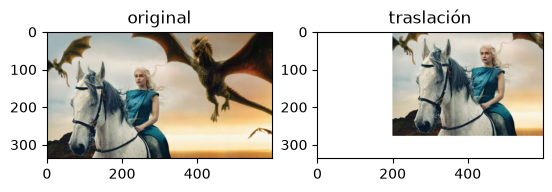

In [35]:
# TRASLACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape
M = np.float32([[1,0,200],[0,1,-60]]) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()


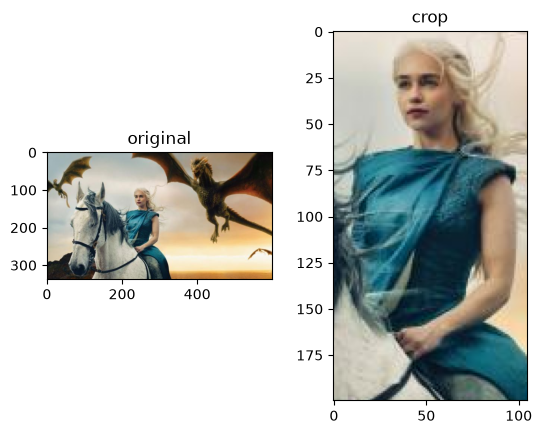

In [36]:
# CROPPING
img = io.imread('images/GOT.png')
new_img = img[90:290, 200:305]
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()


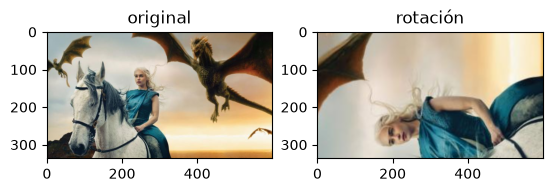

In [37]:
# ROTACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape
M = cv2.getRotationMatrix2D((cols/2,rows/2),angle=90,scale=2) 
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()


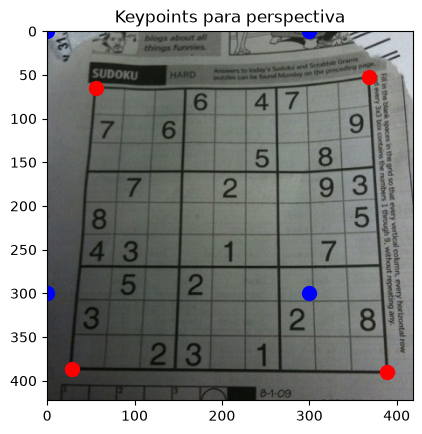

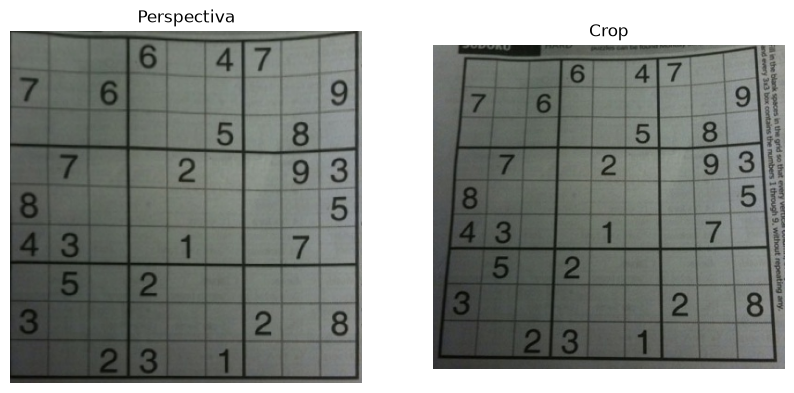

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# PERSPECTIVA

# Leer la imagen
img = cv2.imread('images/sudoku.png')

# Obtener dimensiones de la imagen
rows, cols, ch = img.shape

# Convertir de BGR (OpenCV) a RGB para visualizar correctamente con matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Puntos de origen (esquinas del tablero en la imagen)
pts1 = np.float32([
    [56, 65],
    [368, 52],
    [28, 387],
    [389, 390]
])

# Puntos de destino (imagen rectificada de 300x300)
pts2 = np.float32([
    [0, 0],
    [300, 0],
    [0, 300],
    [300, 300]
])

# Mostrar la imagen original
plt.imshow(img_rgb)

# Dibujar los puntos de origen (rojos) y destino (azules)
for i in range(4):
    plt.plot(pts1[i, 0], pts1[i, 1], 'or', markersize=10)
    plt.plot(pts2[i, 0], pts2[i, 1], 'ob', markersize=10)

plt.title('Keypoints para perspectiva')
plt.show()

# Calcular la matriz de transformación de perspectiva
M = cv2.getPerspectiveTransform(pts1, pts2)

# Aplicar la transformación
pers = cv2.warpPerspective(img_rgb, M, (305, 305))

# Recorte de la imagen original para comparación
crop = img_rgb[50:400, 20:400]

# Mostrar resultados
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(pers)
ax[0].set_title('Perspectiva')
ax[0].axis('off')

ax[1].imshow(crop)
ax[1].set_title('Crop')
ax[1].axis('off')

plt.show()

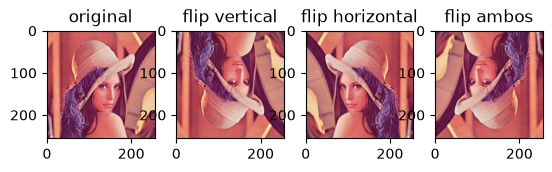

In [45]:
# FLIPPING
# Leer la imagen "Lena_RGB.png" en formato RGB
img = io.imread('images/Lena_RGB.png')
# Voltear la imagen para conseguir las siguientes transformaciones. Utiliza el
"cv2.flip()"
flipVertical = cv2.flip(img,0)
flipHorizontal = cv2.flip(img,1)
flipBoth = cv2.flip(img,-1)
4
figs, ax = plt.subplots(1,4)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(flipVertical, cmap='gray'), ax[1].set_title('flip vertical')
ax[2].imshow(flipHorizontal, cmap='gray'), ax[2].set_title('flip horizontal')
ax[3].imshow(flipBoth, cmap='gray'), ax[3].set_title('flip ambos')
plt.show()
